<center><h1> Agent-Based Model of Panic</h1> </center>

## Imports

In [1]:
import random
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd
from scipy import stats
import statistics
import math
import numpy as np
import seaborn as sns
from itertools import product

In [15]:
plt.rc('figure', figsize=(12, 8))
plt.rcParams['font.size'] = '24'
sns.set_palette("Paired")


## Reproducibility & Experiment Helpers

The following helper functions make it easier to reproduce simulations,
run experiments, and explore parameter spaces when using this notebook.


In [4]:
def set_seed(seed=122):
    """Set Python and NumPy seeds for reproducible simulations."""
    random.seed(seed)
    np.random.seed(seed)

def run_experiment(num_agents, num_iterations, agent_groups, seed=122):
    """Run a simulation and return the model + results dataframe."""
    set_seed(seed)
    model = Model(num_of_agents=num_agents,
                  num_iterations=num_iterations,
                  agent_groups=agent_groups)
    model.run()
    return model, model.result

def sweep_parameters(betas, alphas, proportion=1.0,
                     num_agents=1000, num_iterations=300,
                     group_name="Group1", seed=122):
    """Run a grid sweep over alpha/beta parameters."""
    rows = []
    
    for beta, alpha in product(betas, alphas):
        
        agent_groups = {group_name: [beta, alpha, proportion]}
        
        model, df = run_experiment(
            num_agents=num_agents,
            num_iterations=num_iterations,
            agent_groups=agent_groups,
            seed=seed
        )
        
        peak = df["num_infected"].max()
        final = df["num_infected"].iloc[-1]
        
        rows.append({
            "beta": beta,
            "alpha": alpha,
            "peak_infected": peak,
            "final_infected": final
        })
        
    return pd.DataFrame(rows)


## Plotting Utilities

Reusable plotting functions for analysing simulation results.


In [5]:
def apply_plot_style():
    """Apply consistent plotting style."""
    plt.rc('figure', figsize=(12, 8))
    plt.rcParams['font.size'] = 24
    sns.set_style("ticks")

def plot_infected(results_df, title="Infected over time"):
    """Plot number of infected agents across iterations."""
    
    fig, ax = plt.subplots()
    
    ax.plot(results_df["num_infected"])
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Number infected")
    ax.set_title(title)
    
    return fig, ax


## Model Class

In [6]:
class Model():

    def __init__(self, num_of_agents, num_iterations, agent_groups): 
        
        self.num_of_agents = num_of_agents
        self.num_iterations = num_iterations
        self.agent_groups = agent_groups

        self.time = 0 #model time
        
        #creating lists
        self.num_infected_per_iteration = []
        self.num_infected_per_iteration_groups = []
        
        #create the agents
        self.agents = []
        
        for key in self.agent_groups.keys():
#             print(key)
            for i in range(round(self.agent_groups[key][2] * num_of_agents)):
                agent = Agent(self, key, key[0], key[1])
                agent.beta = self.agent_groups[key][0]
                agent.alpha = self.agent_groups[key][1]
#                 print(agent)
                self.agents.append(agent)
        
        self.infected_per_group = {}
        
        for g in self.agent_groups:
            self.infected_per_group[g] = []
        

    def get_num_infected(self):
        return len(([a for a in self.agents if a.state==1])) 

    def get_num_infected_iteration_groups(self, group_number):
        return len(([ a for a in self.agent_groups[group_number] if a.state==1 ]))
    
    def run(self):
        for t in range(self.num_iterations):
            for agent in self.agents:
                if t >=1:
                    agent.step()
           
            for g in self.agent_groups:
                group_agents = [a for a in self.agents if a.group == g]
                num_infected = sum([a.state for a in group_agents])
                self.infected_per_group[g].append(num_infected)
        
            self.num_infected_per_iteration.append(self.get_num_infected())
        
        
            self.data = pd.DataFrame(self.infected_per_group)
            self.data.reset_index(inplace = True, drop = False)
            
            self.dataset = pd.DataFrame(self.num_infected_per_iteration)
        
            
            self.result = pd.merge(self.data, self.dataset, left_index=True, right_index=True)
            self.result.rename(columns={self.result.columns[-1]: "num_infected" }, inplace = True)
        
    
            self.time += 1


## Agent Class

In [7]:
class Agent():
    
    def __init__(self, model, group, beta=0, alpha=0, gamma=0.1):
        
        #intialising parameters
        self.state = 0
        
        self.alpha = alpha
        self.gamma = gamma
        self.beta = beta 
        
        self.model = model
        
        self.group = group
        
        self.likelihood = 0

    def step(self):
        if self.state == 0:
            self.become_panicked()
            
        else:
            self.recover()
    
    
    def __repr__(self):
        return f"agent beta {self.beta}"
        
    def become_panicked(self):
        
        Agent_i = random.choice(self.model.agents)
        
        if Agent_i.state == 1:
            self.likelihood = self.alpha + self.beta
        else:
            self.likelihood = self.alpha
        
        r_v = random.random()
        if r_v < self.likelihood: 
            self.state = 1

#         for i, agent in enumerate(model.agents):
#             print('Agent {0}/{1}:'.format(i, model.num_of_agents)) 
#             print('Likelihood:{}, my state:{}'.format(self.likelihood, self.state))
            
       
    def recover(self): 
        r_v = random.random()
        if self.state == 1:
            if r_v < self.gamma:
                self.state = 0

## Running model

In [21]:
set_seed(122)

### Homogeneous Config

In [10]:
agent_groups = {'Group1': [0.2, 0.01, 1.0]} #008957
homo_model = Model(num_of_agents=1000, num_iterations=1000, agent_groups=agent_groups)
homo_model.run()

In [11]:
homo_model.result

,index,Group1,num_infected
0,0,0,0
1,1,14,14
2,2,31,31
3,3,48,48
4,4,58,58
...,...,...,...
995,995,549,549
996,996,530,530
997,997,521,521
998,998,520,520


In [22]:
model, results = run_experiment(num_agents=1000, num_iterations=1000, agent_groups={"Group1": [0.2, 0.01, 1.0]},)

In [23]:
results.head()

,index,Group1,num_infected
0,0,0,0
1,1,14,14
2,2,32,32
3,3,51,51
4,4,73,73


### Heterogeneus Config

In [12]:
agent_groups = {'Group1': [0.2, 0.01, 0.5], 'Group2': [0.6, 0.01, 0.5]} #008957
hete_model = Model(num_of_agents=1000, num_iterations=1000, agent_groups=agent_groups)
hete_model.run()

In [16]:
hete_model.result

,index,Group1,Group2,num_infected
0,0,0,0,0
1,1,2,12,14
2,2,10,25,35
3,3,22,52,74
4,4,23,77,100
...,...,...,...,...
995,995,279,398,677
996,996,281,398,679
997,997,285,389,674
998,998,290,398,688


### Plots

In [24]:
apply_plot_style()

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Infected over time'}, xlabel='Iteration', ylabel='Number infected'>)

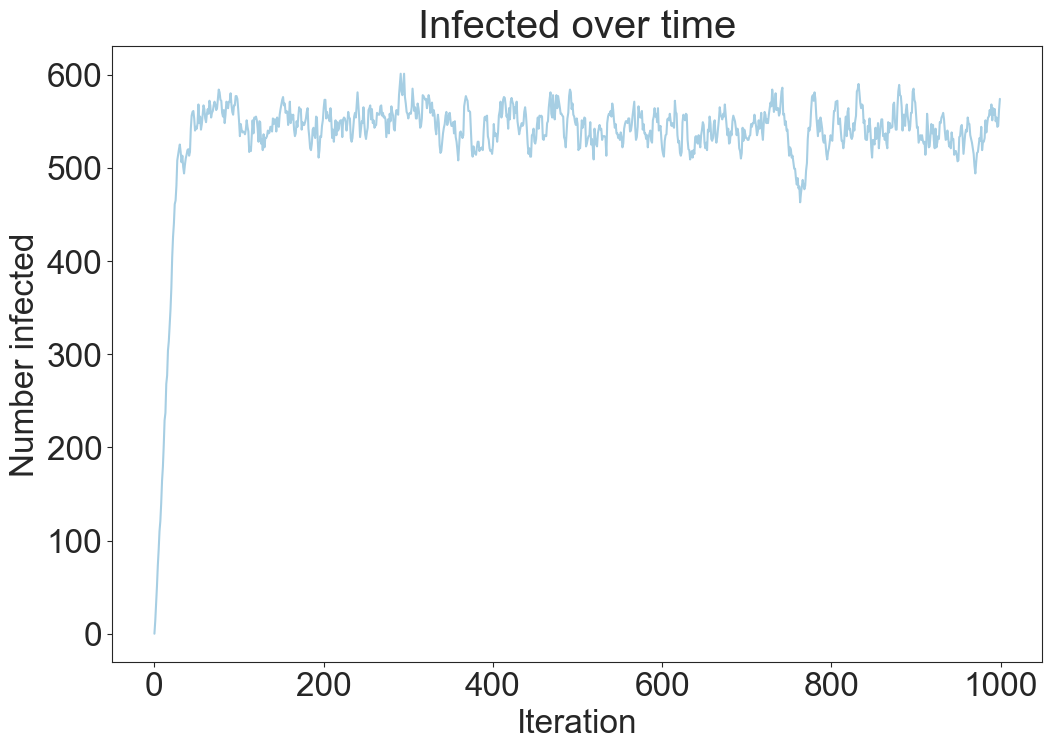

In [25]:
plot_infected(results)

In [32]:
betas = np.arange(0, 1.05, 0.1)
alphas = np.arange(0, 0.105, 0.01)

grid = sweep_parameters(betas, alphas)

In [33]:
grid.sort_values("peak_infected", ascending=False)

,beta,alpha,peak_infected,final_infected
113,1.0,0.03,933,901
120,1.0,0.10,930,891
116,1.0,0.06,930,900
107,0.9,0.08,930,885
109,0.9,0.10,930,891
...,...,...,...,...
33,0.3,0.00,0,0
77,0.7,0.00,0,0
44,0.4,0.00,0,0
66,0.6,0.00,0,0


Text(0.5, 1.0, 'Peak Panic Levels')

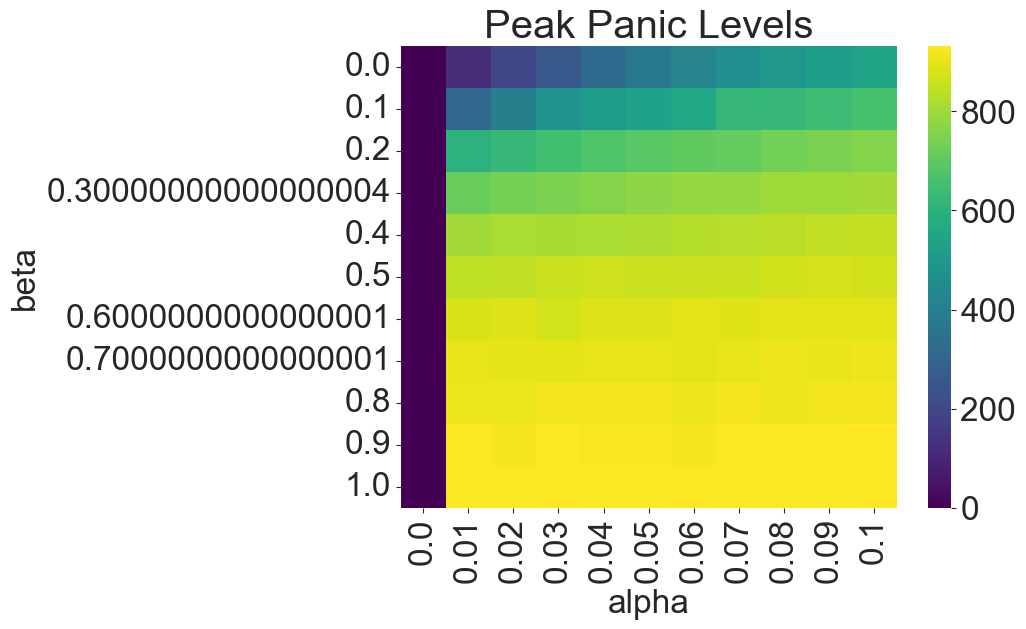

In [34]:
pivot = grid.pivot(index="beta", columns="alpha", values="peak_infected")

plt.figure(figsize=(8,6))
sns.heatmap(pivot, cmap="viridis")

plt.xlabel("alpha")
plt.ylabel("beta")
plt.title("Peak Panic Levels")